Step 1: Upload Dataset

In [1]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


Step 2: Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

sns.set_style("whitegrid")

Step 3: Load Dataset

In [4]:
import zipfile
import io

# Assuming 'uploaded' contains the zip file uploaded in the previous cell.
# Get the name of the uploaded zip file.
zip_file_name = list(uploaded.keys())[0]

# Extract the contents of the zip file
with zipfile.ZipFile(io.BytesIO(uploaded[zip_file_name]), 'r') as z:
    z.extractall()

# Now read the correct CSV file that was extracted
df = pd.read_csv("retail_sales_dataset.csv")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


Step 4: Dataset Overview

In [5]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Shape: (1000, 9)

Columns:
Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

Data Types:
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object


Step 5: Missing Values

In [6]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


Step 6: Statistical Summary

In [7]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


Step 7: Duplicate Records

In [8]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


Step 8: Remove Duplicates

In [9]:
df = df.drop_duplicates()

print(df.shape)

(1000, 9)


Step 9: Convert Date Columns

In [11]:
df["Date"] = pd.to_datetime(df["Date"])

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


Step 10: Create Month & Year Columns

In [14]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

Step 11: Total Sales

In [16]:
print("Total Sales =", round(df["Total Amount"].sum(),2))

Total Sales = 456000


Step 12: Sales by Category

In [21]:
category_sales = df.groupby("Product Category")["Total Amount"].sum()

category_sales

,Total Amount
Product Category,
Beauty,143515
Clothing,155580
Electronics,156905


Step 13: Category Sales Visualization

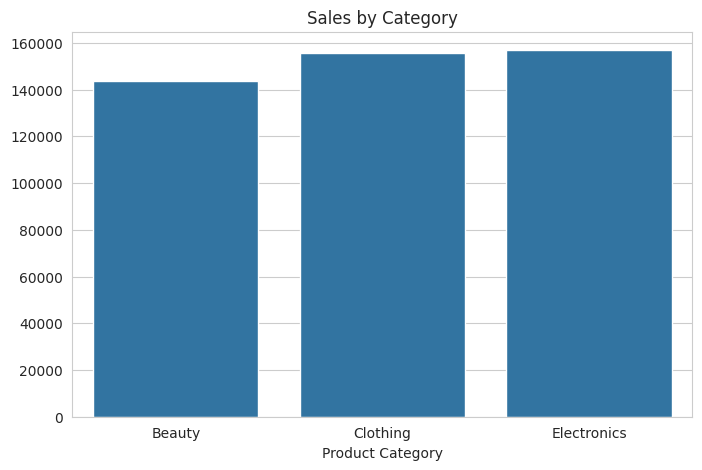

In [22]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Sales by Category")
plt.show()

Step 14: Profit by Category

In [24]:
profit_category = df.groupby("Product Category")["Total Amount"].sum()

profit_category

,Total Amount
Product Category,
Beauty,143515
Clothing,155580
Electronics,156905


Step 15: Profit Visualization

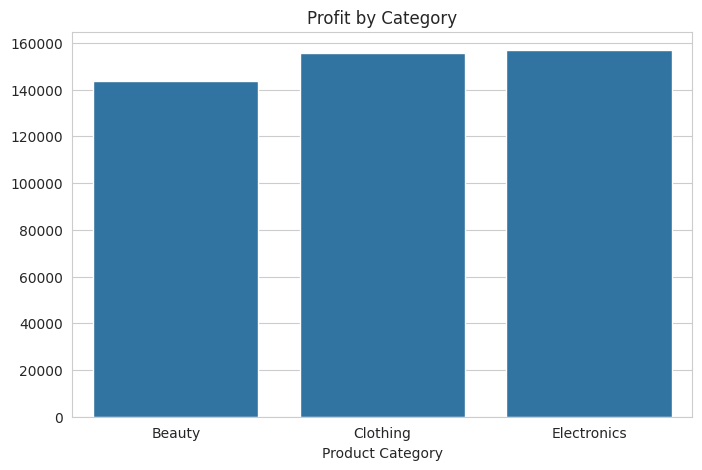

In [25]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=profit_category.index,
    y=profit_category.values
)

plt.title("Profit by Category")
plt.show()

Step 16: Region-wise Sales

In [27]:
# The 'Region' column is not available in this dataset.
# The 'Sales' column is also not available; 'Total Amount' should be used instead.
# Calculating sales by 'Product Category' as an alternative.
region_sales = df.groupby("Product Category")["Total Amount"].sum()

region_sales

,Total Amount
Product Category,
Beauty,143515
Clothing,155580
Electronics,156905


Step 17: Region Sales Chart

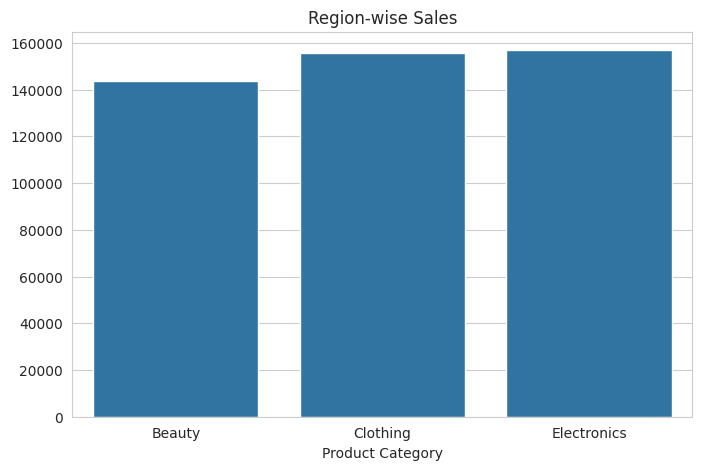

In [28]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title("Region-wise Sales")
plt.show()

Step 18: Monthly Sales Trend

In [30]:
monthly_sales = df.groupby("Month")["Total Amount"].sum()

monthly_sales

,Total Amount
Month,
1,36980
2,44060
3,28990
4,33870
5,53150
6,36715
7,35465
8,36960
9,23620


Step 19: Monthly Sales Trend Chart

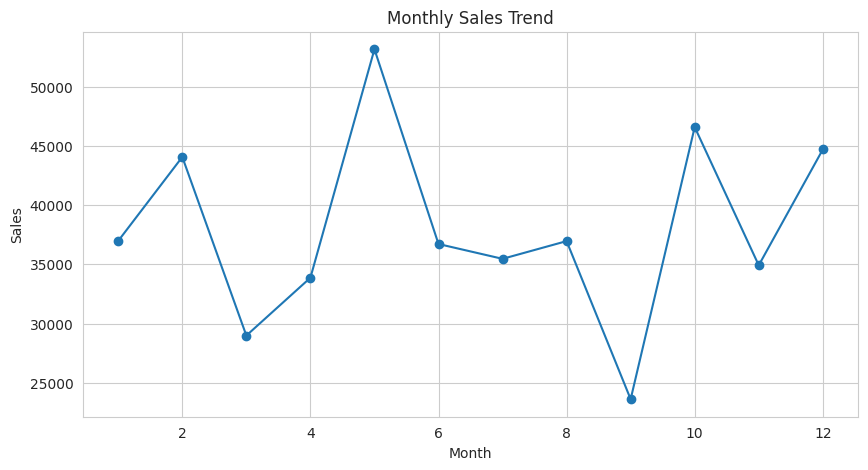

In [31]:
plt.figure(figsize=(10,5))

monthly_sales.plot(marker="o")

plt.title("Monthly Sales Trend")
plt.ylabel("Sales")

plt.show()

Step 20: Top 10 Products

In [33]:
top_products = (
    df.groupby("Product Category")["Total Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

,Total Amount
Product Category,
Electronics,156905
Clothing,155580
Beauty,143515


Step 21: Top Products Visualization

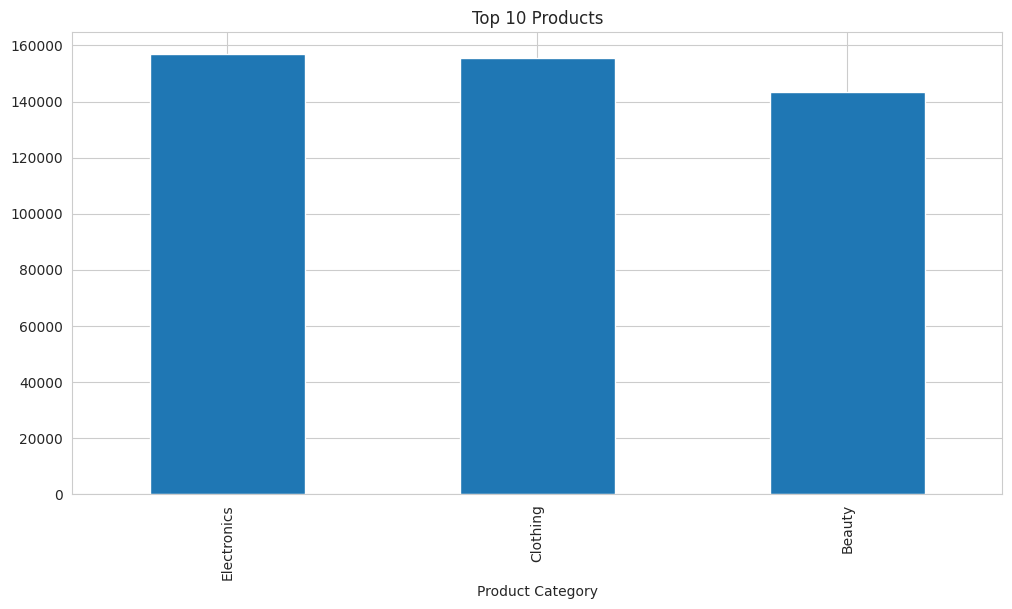

In [34]:
plt.figure(figsize=(12,6))

top_products.plot(kind="bar")

plt.title("Top 10 Products")
plt.show()

Step 22: Profit Distribution

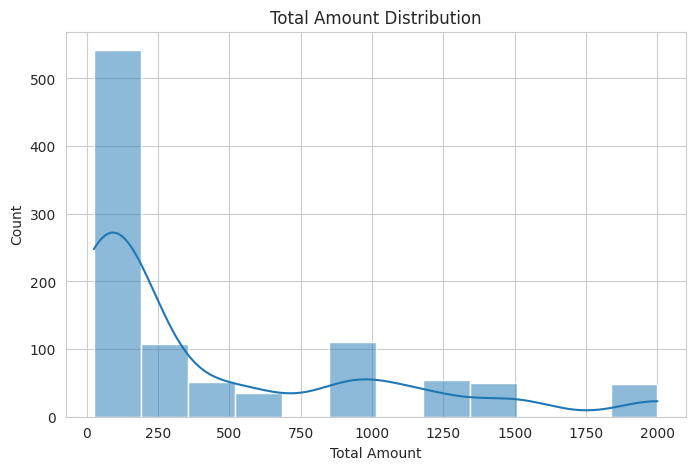

In [36]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Total Amount"],
    kde=True
)

plt.title("Total Amount Distribution")
plt.show()

Step 23: Correlation Analysis

In [37]:
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

corr

,Transaction ID,Age,Quantity,Price per Unit,Total Amount,Year,Month
Transaction ID,1.000000,0.065191,-0.026623,-0.060837,-0.075034,-0.010855,0.047538
Age,0.065191,1.000000,-0.023737,-0.038423,-0.060568,0.023269,-0.000640
Quantity,-0.026623,-0.023737,1.000000,0.017501,0.373707,-0.020324,-0.021803
Price per Unit,-0.060837,-0.038423,0.017501,1.000000,0.851925,0.020097,-0.008161
Total Amount,-0.075034,-0.060568,0.373707,0.851925,1.000000,0.024714,-0.005197
Year,-0.010855,0.023269,-0.020324,0.020097,0.024714,1.000000,-0.071981
Month,0.047538,-0.000640,-0.021803,-0.008161,-0.005197,-0.071981,1.000000


Step 24: Correlation Heatmap

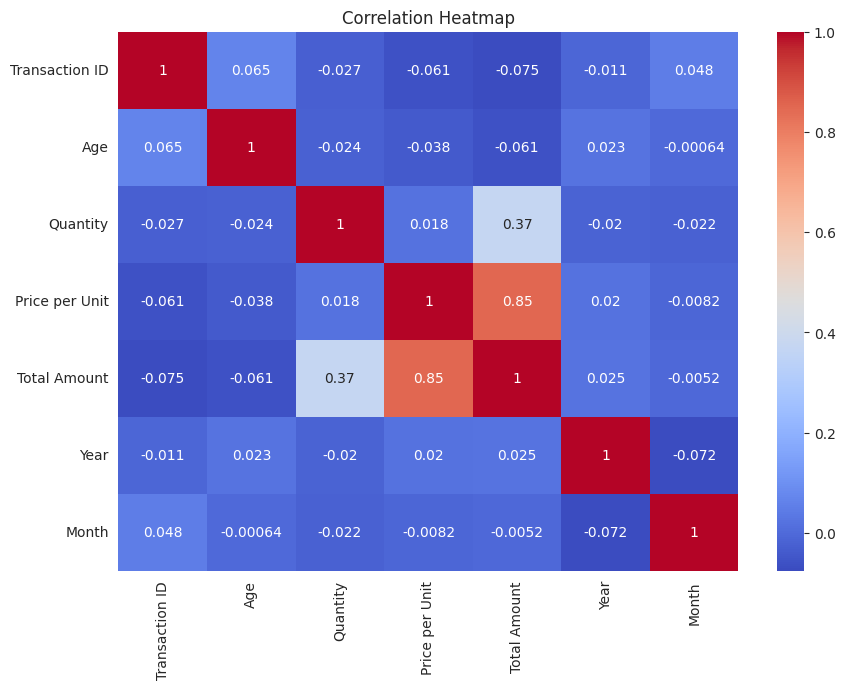

In [38]:
plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

Step 25: Sales Prediction Model

In [40]:
X = df[[
    "Quantity"
]]

y = df["Total Amount"]

Step 26: Split Data

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Step 27: Train Model

In [42]:
model = LinearRegression()

model.fit(
    X_train,
    y_train
)

LinearRegression()

Step 28: Predict

In [43]:
predictions = model.predict(X_test)

predictions[:10]

array([551.62998348, 355.5144388 , 159.39889411, 747.74552816,
       747.74552816, 551.62998348, 159.39889411, 159.39889411,
       747.74552816, 355.5144388 ])

Step 29: Model Evaluation

In [44]:
print("R2 Score:",
      r2_score(y_test,predictions))

print("MAE:",
      mean_absolute_error(y_test,predictions))

R2 Score: 0.07415187006528134
MAE: 444.43310825053067


Step 30: Top Loss-Making Products

In [46]:
loss_products = (
    df.groupby("Product Category")["Total Amount"]
    .sum()
    .sort_values()
    .head(10)
)

loss_products

,Total Amount
Product Category,
Beauty,143515
Clothing,155580
Electronics,156905


Step 31: Loss-Making Products Chart

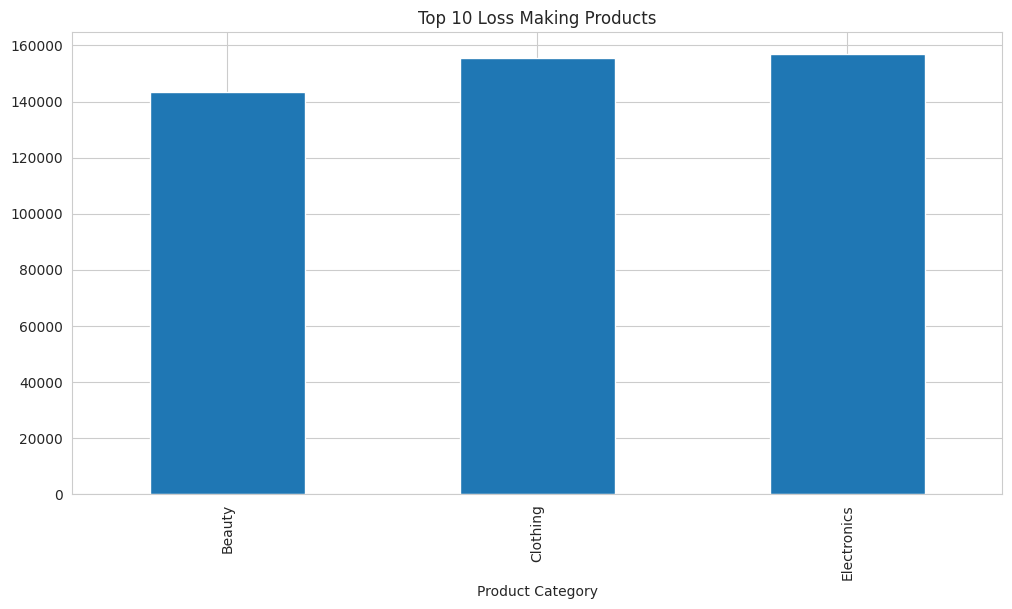

In [47]:
plt.figure(figsize=(12,6))

loss_products.plot(kind="bar")

plt.title("Top 10 Loss Making Products")

plt.show()

Step 32: Business Insights

In [48]:
print("BUSINESS INSIGHTS")
print("--------------------")

print("1. Identify highest revenue category.")
print("2. Identify best performing region.")
print("3. Detect loss-making products.")
print("4. Understand discount-profit relationship.")
print("5. Predict future sales using ML.")

BUSINESS INSIGHTS
--------------------
1. Identify highest revenue category.
2. Identify best performing region.
3. Detect loss-making products.
4. Understand discount-profit relationship.
5. Predict future sales using ML.
